In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# завантаження бази даних для роботи
df = pd.read_csv('drive/MyDrive/ecommerce_customer_data_custom_ratios.csv')

# [Аналіз поведінки споживачів](https://www.kaggle.com/datasets/bhanupratapbiswas/customer-behavior-analysis)
Аналіз поведінки споживачів передбачає вивчення та розуміння того, як споживачі взаємодіють з продуктами чи послугами. Цей аналіз допомагає бізнесу отримати уявлення про вподобання клієнтів, моделі купівлі, процеси прийняття рішень та загальну задоволеність. Метою аналізу поведінки клієнтів є підвищення рівня залученості, утримання клієнтів і, зрештою, збільшення прибутковості шляхом приведення бізнес-пропозицій у відповідність до потреб та очікувань клієнтів.


---



Інформація, що міститься в базі даних:
Customer ID - ID клієнта;
Purchase Date - Дата покупки;
Product Category - Категорія товарів;
Product Price - Ціна товарів;
Quantity - Кількість;
Total Purchase Amount - Загальна сума чеку;
Payment Method - Метод оплати;
Customer Age - Вік покупця;
Returns - Повернення покупки;
Customer Name - Ім'я покупця;
Age - Вік покупця;
Gender - Стать покупця;
Churn - Відтік клієнтів.

In [4]:
# перегляд бази даних для огляду присутньої в ній інформації, для оцінки подальшого плану дій
df.head(5)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [5]:
num_rows, num_columns = df.shape
print(f'Набір данних містить {num_rows} рядків, та {num_columns} колонок')

Набір данних містить 250000 рядків, та 13 колонок


In [6]:
# перевірка типу даних в кожній колонці
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


# 1. Очищення даних від пропущених значень і дублікатів.

In [7]:
# перевірка на пропущені значення
df.isna().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [8]:
# очищення пропущених значень
df.dropna(inplace = True)
df.shape

(202404, 13)

In [9]:
# перевірка на дублікати
df.duplicated().any()

False

В таблиці присутні два стовпці які відображають однакову інформацію: Customer Age та Age. Оскільки інформація ідентична, приберемо зайву колонку Age.

In [10]:
df.drop(columns = ["Age"], inplace = True)

# 2. Визначити які категорії товарів мають найбільші прибутки.

In [11]:
# визначення найпопулярнішої категорії товарів
df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending = False)

,Total Purchase Amount
Product Category,
Books,165765436
Clothing,165415963
Electronics,110525945
Home,109870033


In [12]:
# визначення найдорощих товарів
df.groupby('Product Category')['Product Price'].mean().sort_values(ascending = False)

,Product Price
Product Category,
Books,254.686707
Home,254.555946
Electronics,254.551738
Clothing,253.833292


In [13]:
# визначення кількості покупок в кожній категорії за гендерами
products_by_gender = df.groupby('Product Category')['Gender'].value_counts()
products_by_gender

Product Category  Gender
Books             Female    30341
                  Male      30254
Clothing          Female    30763
                  Male      29966
Electronics       Female    20359
                  Male      20298
Home              Female    20335
                  Male      20088
Name: count, dtype: int64

Результат: найбрибутковіша категорія "Книжки", а також найбільша середня ціна теж для цієї категорії. В категорії "Книжки", "Електроника" кількість покупок різними гендерами відрізняється мінімально. Тому висновок, що ця категорія товарів актуальна як для жінок, так і для чоловіків.
Для категорій "Одяг", "Дім" по кількості покупок лідирують жінки. Найбільш відчутна різниця для категорії "Одяг".
Потрібно перевірити ці результати до загального прибутку по гендеру, порівняти суми загальних покупок по цих категоріях. Перевірити можливість того, що чоловіки/жінки купили меншу кількість товарів, але більшої вартості.


---




# 3. Визначити які категорії товарів, для кожного гендеру, принесли більше прибутку

In [14]:
sum_by_gender = df.pivot_table(index = 'Gender', columns = 'Product Category', values = 'Total Purchase Amount', aggfunc = 'sum')
sum_by_gender

Product Category,Books,Clothing,Electronics,Home
Gender,,,,
Female,83007692,84096199,55204319,55298712
Male,82757744,81319764,55321626,54571321


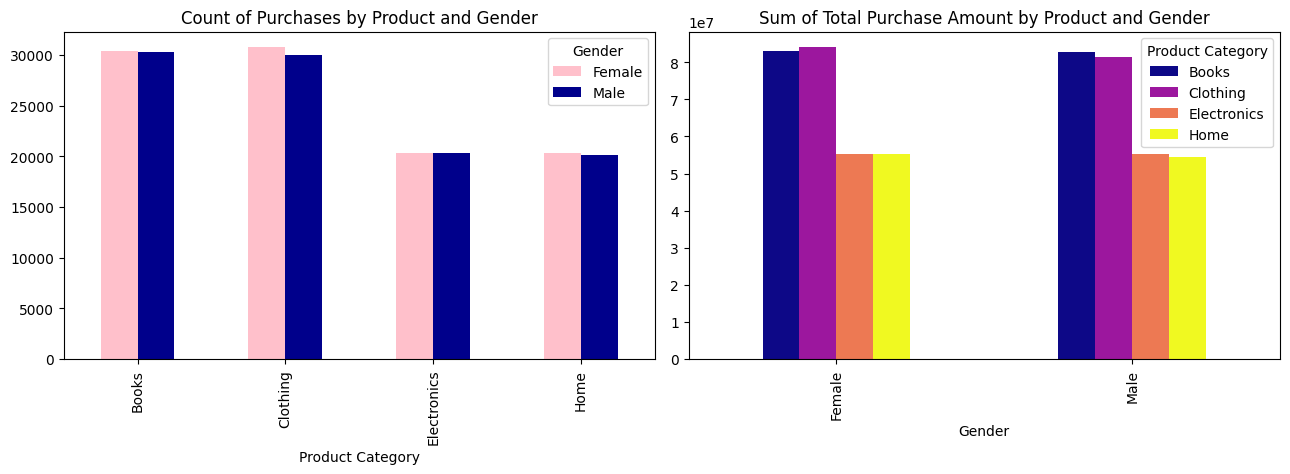

In [15]:
# візуалізація двух співвідношень Гендер до кількості покупок в кожній категорії, та Гендер до суми вартості покупок по категоріям
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

products_by_gender.unstack().plot(kind = 'bar', ax = axes[0], color = ['pink', 'darkblue'])
axes[0].set_title("Count of Purchases by Product and Gender")

sum_by_gender.plot(kind = 'bar', ax = axes[1], colormap = 'plasma')
axes[1].set_title("Sum of Total Purchase Amount by Product and Gender")

plt.tight_layout()
plt.show()

Результат: візуалізація наочно відображає те, що чоловіки витратили на книжки більше грошей, хоча кількість покупок майже не відрізнялась. Категорія "Одяг" показала перевагу в бік жінок, вони зробили і більшу кількість покупок, і загальна вартість теж більша. В категорії "Електроника" загальна кількість покупок між двома гендерами майже не відрізнялась, а ось загальна сума витрат більша у чоловіків. І в категорії "Дім" жінки зробили більше покупок, на більшу загальну вартість.
Висновок: для жінок лідирують товари в категоріях "Одяг" і "Дім". Можна розширювати асортимент, щоб збільшити продажі.

---



# 4. Визначити топ 10 найприбутковіших клієнтів.

In [16]:
top_customers = df.groupby('Customer Name')['Total Purchase Amount'].sum()
top_10_customers = top_customers.sort_values(ascending = False).head(10)
top_10_customers

,Total Purchase Amount
Customer Name,
John Smith,248739
Lisa Smith,222191
Michael Smith,220997
Jennifer Smith,218548
James Smith,217355
Michael Johnson,204132
Christopher Smith,179725
Christopher Jones,167849
Michael Williams,164152


Результат: отримавши список покупців, які витратили найбільше, бачим що 8 з 10 позицій займають чоловіки. Висновок, саме чоловіки роблять найбільш витратні покупки.


---



# 5. Визначити на які години припадає найбільша кількість покупок.

In [17]:
# розділяємо дані в колонці Purchase Date окремо на час
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [18]:
df['Time'] = df['Purchase Date'].dt.hour  # створюємо колонку з часом

In [19]:
hours = df.groupby('Time')['Total Purchase Amount'].sum()
hours
# з отриманих даних важко зрозуміти в які часи було найбільше покупок, тому зробим візуалізацію

,Total Purchase Amount
Time,
0,23459139
1,23005021
2,22797807
3,22988640
4,22475036
5,22478473
6,23116270
7,23488383
8,23425734


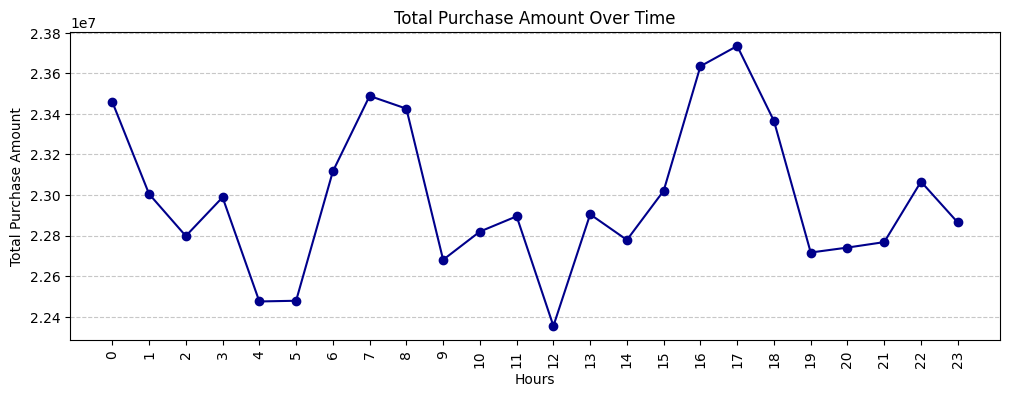

In [20]:
plt.figure(figsize = (12, 4))
plt.plot(hours.index, hours.values, marker = 'o', color = 'darkblue', linestyle = '-')

plt.xlabel('Hours')
plt.ylabel('Total Purchase Amount')
plt.title('Total Purchase Amount Over Time')
plt.xticks(hours.index, rotation=90)
plt.grid(axis = 'y', linestyle = "--", alpha = 0.7)

plt.show()

Результат: на графіку чітко прослідковується пік покупок з 16:00 до 18:00, час який припадає на те, коли люди закінчують роботу і заходять до крамниці після роботи.
Також трохи менше зроблено покупок в години з 7:00 до 9:00, час коли люди йдуть на роботу, відповідно перед цим вони забігають в магазин.
Висновок: В години "пік" можна збільшити кількість персоналу, щоб зменшити час очікування людей на касах.

---

# 6. Визначити на які дні припадає найбільше покупок.

In [21]:
df['Day of Week'] = df['Purchase Date'].dt.day_name()
sum_by_day_of_week = df.groupby('Day of Week')['Total Purchase Amount'].sum().sort_values(ascending = False)
sum_by_day_of_week

,Total Purchase Amount
Day of Week,
Friday,79465426
Wednesday,79422535
Monday,78847312
Tuesday,78644516
Saturday,78611097
Thursday,78531370
Sunday,78055121


Результат: найбільшу суму на покупки було витрачено в п'ятницю, та середу. Висновок: покупці роблять закупи перед вихідними, щоб не витрачати час в вихідний день на шопінг. Також роблять багато покупок посеред тижня, що вказує на те що, запаси продуктів закінчуються до середини тижня.


---



# 7. Визначити найбільш популярний метод оплати товарів.

In [22]:
payment_counts = df['Payment Method'].value_counts()
payment_counts

,count
Payment Method,
Credit Card,81394
PayPal,60603
Cash,40406
Crypto,20001


In [23]:
pivot = df.pivot_table(index = ['Gender'], columns = ['Payment Method'], values = ['Total Purchase Amount'])
display(pivot.style.background_gradient(axis = 0))

Результат: найзручніший метод оплати для покупців Кредитна карта, також трохи менш зручний вид оплати - PayPal. Прослідковується те, що жінки надають перевагу елекронним розрахункам, а чоловікам зручно користуватись готівкою.


---



# 8. Визначити яка вікова група витрачає найбільше.

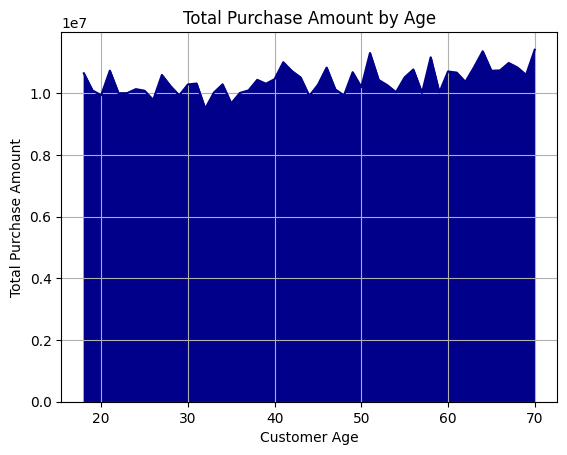

In [24]:
df.groupby('Customer Age')['Total Purchase Amount'].sum().plot(kind = 'area', color = 'darkblue')
plt.ylabel('Total Purchase Amount')
plt.title('Total Purchase Amount by Age')
plt.grid();

Результат: чіткої закономірності в віці покупців немає. Категорія людей 40+ витрачає трохи більше.


---



# 9. Визначити які категорії товарів повертають найчастіше.

In [25]:
df.groupby('Product Category')['Returns'].sum().sort_values(ascending = False)

,Returns
Product Category,
Books,30229.0
Clothing,30122.0
Electronics,20271.0
Home,20147.0


In [28]:
df.groupby('Product Category')['Churn'].mean().sort_values(ascending = False)

,Churn
Product Category,
Home,0.202038
Electronics,0.199326
Clothing,0.198653
Books,0.198515


Результат:

# 10. Визначити